Work in progress

Evolution of eigenvalues over time to check for interlacing eigenvalues in shock tube problem

In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [2]:
# Matplotlib settings
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# For Comparison
T_end = 0.3
base_tree_level = 10
polydeg = 1
Kn = 0.1
sourcestring = "relaxation_source"

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

## Analytical

In [4]:
from sympy import *
u0, u1, u2, u3, u4, u5 = symbols('u0 u1 u2 u3 u4 u5')
c = symbols('c')
init_printing(use_unicode=True)

In [5]:
x_dest = 0.5

### M=4

In [6]:
M = 4
n = int(M/2)
chi = (n+1) / n

In [7]:
p_nm = lambda c: c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]
p_n = lambda c: c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]
p_np = lambda c: c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42

sigma_nn = Matrix([u4])[0] - Matrix(Matrix([u2, u3]).T * Matrix([[u0, u1],[u1, u2]]).inv() * Matrix([u2, u3]))[0]
sigma_nmnm = u2 - u1 * u1 / u0

P_ExtendedGramian = lambda c: p_n(c) * (p_np(c) - chi * sigma_nn / sigma_nmnm * p_nm(c)) 
P_ExtendedGramianEven = simplify(P_ExtendedGramian(c))

In [8]:
closure = "ExtGram"
file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{sourcestring}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

data = read_solution_file(file)

times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21
sol = interpolate_solution(data, time_query, times, timesteps)
x = sol['x']
u = sol['u']

In [9]:
eigenvalues = []
max_time_index = 21
time_range = []
for time in times:
    sol = interpolate_solution(data, time, times, timesteps)
    x = sol['x']
    u = sol['u']
    time_range.append(sol['t'])

    x_idx = (np.abs(x - x_dest)).argmin()

    moments = u[x_idx,:]

    subs_dict = {
        u0: moments[0],
        u1: moments[1],
        u2: moments[2],
        u3: moments[3],
        u4: moments[4]
    }
    P_ExtendedGramian_subs = simplify(P_ExtendedGramianEven.subs(subs_dict))

    roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
    max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
    assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
    roots_subs = [float(root.subs(subs_dict).evalf().as_real_imag()[0]) for root in roots]
    eigenvalues.append(roots_subs)

In [10]:
times_M4 = time_range
eigenvalues_M4 = eigenvalues

### M=3

In [11]:
M = 3
n = int((M+1)/2)

In [12]:
# Orthogonal Polynomials (Hardcoded p_k)
p_m1 = sympify(0)
p_0 = sympify(1)
p_1 = simplify(c - u1/u0)
# p_2 uses G_1 and u_{2,3}
G1 = Matrix([[u0, u1], [u1, u2]])
u23 = Matrix([u2, u3])
c_vec1 = Matrix([1, c])
p_2 = simplify(c**2 - (c_vec1.T * G1.inv() * u23)[0])

# Variances sigma_kk (Hardcoded)
sigma_m1m1 = sympify(1)
sigma_00 = u0
sigma_11 = simplify(u2 - u1**2/u0)
# sigma_22 involves u4, which will be substituted by the closure later
sigma_22 = simplify(u4 - (u23.T * G1.inv() * u23)[0])

# Variances sigma_k,k+1 (Hardcoded)
sigma_m1_0 = sympify(0)
sigma_0_1 = u1
u34 = Matrix([u3, u4]) # u_vl for k=1, start_idx=k+1
u23_r = Matrix([u2, u3]) # u_vr for k=1, start_idx=k
sigma_1_2 = simplify(u3 - (Matrix([u2, u3]).T * G1.inv() * Matrix([u1, u2]))[0])

# Recurrence Parameters alpha_k and beta_k (Explicit)
alpha_0 = sigma_0_1 / sigma_00
alpha_1 = (sigma_1_2 / sigma_11) - (sigma_0_1 / sigma_00)

beta_1 = sigma_11 / sigma_00

# Closure Bracket from Eq (67) for n=2
# beta_2 = 2/(n-1) * sum_{k=1}^1 beta_k + 1/(n-1) * sum_{l=0}^1 (alpha_1 - alpha_l)^2
bracket = (2/1) * (beta_1) + (1/1) * ((alpha_1 - alpha_0)**2 + (alpha_1 - alpha_1)**2)

# Moment Closure for u4 from Eq (68)
# u4 = Projection + sigma_{1,1} * bracket
proj_part = (u23.T * G1.inv() * u23)[0]
u4_closure = simplify(proj_part + sigma_11 * bracket)

# Re-define sigma_22 using the closed u4 value
sigma_22_closed = sigma_22.subs(u4, u4_closure)

# Helper terms beta' and alpha' (Explicitly hardcoded for n=2)
# beta'_k = p_k^2/sigma_{k-1,k-1} - sigma_kk * p_{k-1}^2 / sigma_{k-1,k-1}^2
beta_p_1 = (p_1**2 / sigma_00) - (sigma_11 * p_0**2 / sigma_00**2)
beta_p_2 = (p_2**2 / sigma_11) - (sigma_22_closed * p_1**2 / sigma_11**2)

# alpha'_k = p_k * p_{k+1} / sigma_kk - p_{k-1} * p_k / sigma_{k-1,k-1}
# For l=0: alpha'_0 = p_0*p_1/sigma_00 - p_-1*p_0/sigma_-1-1
alpha_p_0 = (p_0 * p_1 / sigma_00)
# For l=1: alpha'_1 = p_1*p_2/sigma_11 - p_0*p_1/sigma_00
alpha_p_1 = (p_1 * p_2 / sigma_11) - (p_0 * p_1 / sigma_00)

# Term 1: beta'_2
term1 = beta_p_2

# Term 2: -2 * beta'_1
term2 = -2 * beta_p_1

# Term 3: -2 * sum_{l=0}^1 (alpha_1 - alpha_l) * (alpha'_1 - alpha'_l)
term3_0 = (alpha_1 - alpha_0) * (alpha_p_1 - alpha_p_0)
term3_1 = (alpha_1 - alpha_1) * (alpha_p_1 - alpha_p_1) # This is 0
term3 = -2 * (term3_0 + term3_1)

# Final Polynomial
P_EG_Odd_M3_Explicit = simplify(term1 + term2 + term3)

In [13]:
file = f"../out/Shock/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{sourcestring}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

data = read_solution_file(file)

times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21
sol = interpolate_solution(data, time_query, times, timesteps)
x = sol['x']
u = sol['u']

In [14]:
eigenvalues = []
time_range = []
for time in times:
    sol = interpolate_solution(data, time, times, timesteps)
    x = sol['x']
    u = sol['u']
    time_range.append(sol['t'])

    x_idx = (np.abs(x - x_dest)).argmin()

    moments = u[x_idx,:]

    subs_dict = {
        u0: moments[0],
        u1: moments[1],
        u2: moments[2],
        u3: moments[3]
    }
    P_EG_Odd_M3_Explicit = simplify(P_EG_Odd_M3_Explicit.subs(subs_dict))

    roots = solve(Eq(P_EG_Odd_M3_Explicit, 0), c)
    max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
    assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
    roots_subs = [float(root.subs(subs_dict).evalf().as_real_imag()[0]) for root in roots]
    eigenvalues.append(roots_subs)

In [15]:
times_M3 = time_range
eigenvalues_M3 = eigenvalues

/tmp/ipykernel_13870/391630820.py:25: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


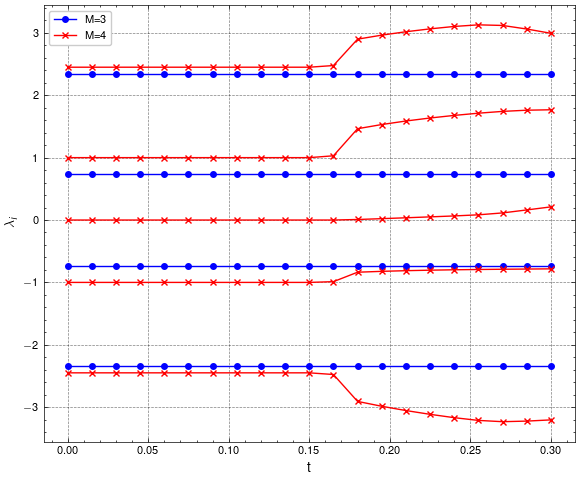

In [16]:
fig, axs = plt.subplots()

# M=3
for mom in range(4):
    value = []
    for i in range(len(time_range)):
        value.append(eigenvalues_M3[i][mom])
    plt.plot(times_M3, value, '-o', color='blue')

# M=4
for mom in range(5):
    value = []
    for i in range(len(time_range)):
        value.append(eigenvalues_M4[i][mom])
    plt.plot(times_M4, value, '-x', color='red')

axs.plot([], [], '-o', color='blue', label='M=3')
axs.plot([], [], '-x', color='red', label='M=4')
axs.legend()

axs.set_xlabel('t')
axs.set_ylabel('$\\lambda_i$')

fig.tight_layout()
fig.show()